# **1. Imports & Functions & Variables**

In [ ]:
# @title
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

#%pip install xgboost
#%pip install catboost
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree, svm
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, \
    recall_score, f1_score, roc_auc_score, roc_curve, classification_report,\
    precision_recall_curve, auc
import shap


# **2. Data Loading & Cleaning**

In [ ]:
# @title
# ▶ Warnings 제거
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# @title
# ▶ 경로 설정 (※강의자료가 위치에 있는 경로 확인)
import os
os.chdir('/content/drive/MyDrive/제로베이스_부트캠프/팀프로젝트')
os.getcwd()

In [ ]:
# @title
# 데이터 불러오기
df = pd.read_csv('BankChurners.csv')
df.head()

In [ ]:
# @title
# 데이터 shape
df.shape

In [ ]:
# @title
# 데이터 요약 정보
df.info()

In [ ]:
# @title
# 결측치 확인
df.isna().sum()

No missing value

In [ ]:
# @title
# 중복 행 확인
df.duplicated().sum()

No duplicated rows

In [ ]:
# @title
# 수치적 의미가 없는 CLIENTNUM은 문자열로 변환, 중복 CLINETNUM 확인
df['CLIENTNUM'] = df['CLIENTNUM'].astype(str)
df.duplicated(subset=['CLIENTNUM']).sum()

No duplicated Client number

In [ ]:
df['Attrited'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)
df['Attrited'].value_counts()

In [ ]:
# 문자열 컬럼 값 확인
obj_cols = df.select_dtypes(include='object').columns

for col in obj_cols[1:]:
    print(f'{df[col].value_counts()}\n')

In [ ]:
# 수치형 데이터 기초 통계 확인
df.describe()

# **3. EDA**

In [ ]:
numeric_cols = ['Total_Trans_Ct', 'Total_Trans_Amt',
                'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1',
                'Total_Relationship_Count', 'Total_Revolving_Bal', 'Months_Inactive_12_mon',
                'Contacts_Count_12_mon', 'Avg_Utilization_Ratio']
labels = ['Total Transaction Count', 'Total Transaction Amount',
                'Transaction Count Change \n (Q4/Q1)', 'Transaction Amount Change \n (Q4/Q1)',
                'Total Relationship Count', 'Total Revolving Balance', 'Months Inactive \n (in 12 months)',
                'Contacts Count \n (in 12 months)', 'Avg Utilization Ratio']

# 수치형 변수 스케일링
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df_scaled['Attrition_Flag'] = df['Attrition_Flag']

# 이탈 여부 그룹별 평균 계산
df_plot = df_scaled.groupby('Attrition_Flag')[numeric_cols].mean().reset_index()

# 시각화
angles = np.linspace(0, 2 * np.pi, len(numeric_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

for i, row in df_plot.iterrows():
    values = row[numeric_cols].tolist()
    values += values[:1]
    label = "Attrited Customer" if row['Attrition_Flag'] == 'Attrited Customer' else "Existing Customer"
    color = "salmon" if row['Attrition_Flag'] == 'Attrited Customer' else "grey"
    ax.plot(angles, values, label=label, color=color)
    ax.fill(angles, values, alpha=0.2, color=color)

ax.set_xticks(angles[:-1])

ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Customer Profile Comparison by Attrition Status', fontsize=16, pad=40)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

print('\n')

treemap_cols = ['Gender', 'Income_Category']

# 성별 x 소득 카테고리 고객 이탈률 계산
segment_data = df.groupby(treemap_cols).agg(
    count=('Attrited', 'size'),
    attrition_rate=('Attrited', 'mean')
).reset_index()

# 시각화
fig = px.treemap(
    segment_data,
    path=[px.Constant("All Customers")] + treemap_cols,
    values='count',
    color='attrition_rate',
    color_continuous_scale='Reds',
    title='Attrition Rate by Gender and Income Category',
    custom_data=['attrition_rate']
)

fig.update_traces(textinfo="label+percent root",
                  hovertemplate=(
                    "<b>%{label}</b><br>"
                    "Attrition Rate: %{customdata[0]:.1%}<br>"
                    "Count: %{value:,}<br>"
                    "Parent: %{parent}<br>"),
                textfont_size=15,
                )
fig.update_layout(width=700,
                  height=400,
                  margin=dict(t=50, b=20, l=20, r=20),
                 title_font=dict(size=24),)
# fig.show()
fig.show(renderer='iframe')

# **4. Modelling**

## 1) Best Model Selection

In [ ]:
df_processed = df.drop(['CLIENTNUM','Attrition_Flag'], axis=1).copy()
X = df_processed.drop(['Attrited'], axis=1)
y = df_processed['Attrited']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=25
)

num_cols = X.select_dtypes(exclude=['object']).columns.to_list()
cat_cols = X.select_dtypes(include=['object']).columns.to_list()

In [ ]:
# One-hot incoding
num_cols = X.select_dtypes(exclude=['object']).columns.to_list()
cat_cols = X.select_dtypes(include=['object']).columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ], verbose_feature_names_out=False)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

new_column_names = preprocessor.get_feature_names_out()

X_train_enc = pd.DataFrame(X_train_enc, columns=new_column_names, index=X_train.index)
X_test_enc = pd.DataFrame(X_test_enc, columns=new_column_names, index=X_test.index)

### Logistic Regression

In [ ]:
# 아웃라이어 완화 -> 왜도 큰 변수 대상 로그 변환
X_train_logistic = X_train_enc.copy()
X_test_logistic = X_test_enc.copy()

# 각 수치형 컬럼의 왜도 값
skewed = X_train_logistic[num_cols].apply(lambda x: x.skew())
skewed_cols = skewed[abs(skewed) > 1].index
for col in skewed_cols:
    X_train_logistic[col] = np.log1p(X_train_logistic[col])
    X_test_logistic[col] = np.log1p(X_test_logistic[col])

In [ ]:
# 다중공산성 검사
vif = pd.DataFrame()
df_vif = X_train_logistic[num_cols]
df_vif = add_constant(df_vif)
vif['Feature'] = df_vif.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_vif.values, i)
                        for i in range(df_vif.shape[1])]
display(vif[vif['VIF_Factor']>5]
        .sort_values(by='VIF_Factor', ascending=False).iloc[1:, :]
        .reset_index(drop=True))

# 상관계수 히트맵
plt.figure(figsize=(10, 10))
corr = X_train_logistic[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1,
            annot=True, annot_kws={'fontsize': 9}, fmt=".2f")
plt.show()

- Avg_Open_To_Buy & Credit_Limit
- Avg_Open_To_Buy & Avg_Utilization_Ratio
    - `Avg_Open_To_Buy` Removed
- Total_Trans_Amt & Total_Trans_Ct
    - `Total_Trans_Amt` Removed


In [ ]:
drop_cols = ['Avg_Open_To_Buy', 'Total_Trans_Amt']
X_train_logistic = X_train_logistic.drop(columns=drop_cols)
X_test_logistic = X_test_logistic.drop(columns=drop_cols)

In [ ]:
# 모델링
logistic_model = LogisticRegression(random_state=25, class_weight='balanced')
logistic_model.fit(X_train_logistic, y_train)
print("Model fitting completed")

### Random Forest

In [ ]:
# Hyper-parameters
# estimators = [50, 150, 250, 350, 450]
# depth = [4, 5, 10, 15]
estimators = [100, 125, 150, 175, 200, 250, 300]
depth = [5, 6, 7, 8, 9]

est_list = []
dep_list = []
prauc_list = []

# 모델링
for est in estimators:
    for dep in depth:
        model = RandomForestClassifier(n_estimators=est,
                                       max_depth=dep,
                                       random_state=25,
                                       class_weight='balanced')
        model.fit(X_train_enc, y_train)

        est_list.append(est)
        dep_list.append(dep)
        y_pred_prob = model.predict_proba(X_test_enc)[:, 1]
        precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
        pr_auc = auc(recall, precision)
        prauc_list.append(pr_auc)
        print(f">>> number of estimators: {est}, max depth: {dep}, PR-AUC: {pr_auc} <<<")

# 튜닝 결과
print("-------------------------------------------------------------------------------")
recall_max_idx = np.argmax(prauc_list)
best_n_estimator = est_list[recall_max_idx]
best_max_depth = dep_list[recall_max_idx]
print(f"best n estimator: {best_n_estimator}, best max depth: {best_max_depth}, PR-AUC: {prauc_list[recall_max_idx]}")

# Best model fitting
best_model_rf = RandomForestClassifier(n_estimators=best_n_estimator,
                                        max_depth=best_max_depth,
                                        random_state=25,
                                        class_weight='balanced')
best_model_rf.fit(X_train_enc, y_train)
print("Model fitting completed")

### CatBoost

In [ ]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight_val = n_neg / n_pos

# Hyper-parameters
iterations = [500, 700, 1000, 1200]
etas = [0.01, 0.03, 0.05, 0.1]
depths = [4, 5, 6]

prauc_list = []
iteration_list = []
eta_list = []
depth_list = []

# 모델링
for iteration in iterations:
    for eta in etas:
        for depth in depths:
            model = CatBoostClassifier(
                iterations=iteration,
                learning_rate=eta,
                depth=depth,
                loss_function='Logloss',
                eval_metric='PRAUC',
                random_state=25,
                verbose=0,
                class_weights=[1, scale_pos_weight_val]
            )
            model.fit(X_train, y_train, cat_features=cat_cols)
            y_pred_prob = model.predict_proba(X_test)[:, 1]
            precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
            pr_auc = auc(recall, precision)
            prauc_list.append(pr_auc)

            iteration_list.append(iteration)
            eta_list.append(eta)
            depth_list.append(depth)
            print(f">>> iteration: {iteration}, eta: {eta}, depth: {depth}, PR-AUC: {pr_auc} <<<")

# 튜닝 결과
print("-------------------------------------------------------------------------------")
best_iteration = iteration_list[np.argmax(prauc_list)]
best_eta = eta_list[np.argmax(prauc_list)]
best_depth = depth_list[np.argmax(prauc_list)]
best_prauc = max(prauc_list)
print(f"best iteration: {best_iteration}, best learning rate: {best_eta}, best depth: {best_depth}, PR-AUC: {best_prauc}")

# 베스트 모델 피팅
best_model_cat = CatBoostClassifier(
                iterations=best_iteration,
                learning_rate=best_eta,
                depth=best_depth,
                loss_function='Logloss',
                eval_metric='PRAUC',
                random_state=25,
                verbose=0,
                class_weights=[1, scale_pos_weight_val]
            )
best_model_cat.fit(X_train, y_train, cat_features=cat_cols)
print("Model fitting completed")


### Linear SVM

In [ ]:
# 데이터 표준화
scaler = StandardScaler()

X_train_std = X_train_enc.copy()
X_test_std = X_test_enc.copy()
X_train_std[num_cols] = scaler.fit_transform(X_train_std[num_cols])
X_test_std[num_cols] = scaler.transform(X_test_std[num_cols])

# Hyper-parameters
C_values = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]

prauc_list = []
for c in C_values:
    model = svm.SVC(kernel='linear', C=c, random_state=25, class_weight='balanced', probability=True)
    model.fit(X_train_std, y_train)
    y_pred_prob = model.predict_proba(X_test_std)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = auc(recall, precision)
    prauc_list.append(pr_auc)

    print(f">>> C: {c}, PR-AUC: {pr_auc} <<<")

# 튜닝 결과
print("-------------------------------------------------------------------------------")
best_c = C_values[np.argmax(prauc_list)]
best_prauc = prauc_list[np.argmax(prauc_list)]
print(f"best C: {best_c}, PR-AUC: {best_prauc}")

# 베스트 모델 피팅
best_model_linear_svm = svm.SVC(kernel='linear', C=best_c, random_state=25, probability=True, class_weight='balanced')
best_model_linear_svm.fit(X_train_std, y_train)
print("Model fitting completed")

### RBF SVM

In [ ]:
# Hyper-parameters
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
gammas = [0.001, 0.005, 0.01, 0.05, 0.1]

c_value_list = []
gamma_list = []
prauc_list = []
for c in C_values:
    for gamma in gammas:
        model = svm.SVC(kernel='rbf', C=c, gamma=gamma, random_state=25, class_weight='balanced', probability=True)
        model.fit(X_train_std, y_train)
        y_pred_prob = model.predict_proba(X_test_std)[:, 1]
        precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
        pr_auc = auc(recall, precision)
        prauc_list.append(pr_auc)
        gamma_list.append(gamma)
        c_value_list.append(c)
        print(f">>> C: {c}, gamma: {gamma}, PR-AUC: {pr_auc} <<<")

# 튜닝 결과
print("-------------------------------------------------------------------------------")
best_c = c_value_list[np.argmax(prauc_list)]
best_gamma = gamma_list[np.argmax(prauc_list)]
best_prauc = prauc_list[np.argmax(prauc_list)]
print(f"best C: {best_c}, best gamma: {best_gamma}, PR-AUC: {best_prauc}")

# 베스트 모델 피팅
best_model_rbf_svm = svm.SVC(kernel='rbf', C=best_c, gamma=best_gamma,
                             class_weight='balanced', random_state=25, probability=True)
best_model_rbf_svm.fit(X_train_std, y_train)
print("Model fitting completed")

### KNN

In [ ]:
# 오버샘플링
smote = SMOTE(random_state=25)
X_train_sm, y_train_sm = smote.fit_resample(X_train_std, y_train)

# Hyper-parameters
k_nums = [5, 11, 21, 31, 51, 71, 91, 101, 121, 141]

prauc_list = []
# 모델링
for k in k_nums:
    model = KNeighborsClassifier(n_neighbors=k, weights='distance')
    model.fit(X_train_sm, y_train_sm)
    y_pred_prob = model.predict_proba(X_test_std)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = auc(recall, precision)
    prauc_list.append(pr_auc)
    print(f">>> K: {k}, PR-AUC: {pr_auc} <<<")

# 튜닝 결과
print("-------------------------------------------------------------------------------")
best_k = k_nums[np.argmax(prauc_list)]
best_prauc = max(prauc_list)
print(f"best K: {best_k}, recall: {best_prauc}")

# 베스트 모델 피팅
best_model_knn = KNeighborsClassifier(n_neighbors=best_k,  weights='distance')
best_model_knn.fit(X_train_sm, y_train_sm)
print("Model fitting completed")

### Performance Comparison

In [ ]:
fitted_model = [logistic_model, best_model_rf, best_model_cat,
                best_model_linear_svm, best_model_rbf_svm, best_model_knn]
model_lst = ['Logistic', 'RandomForest', 'CatBoost',
             'Linear SVM', 'RBF SVM', 'KNN']
precision_lst = []
recall_lst = []
f1_score_lst = []
auc_lst = []
prauc_lst = []

for model in fitted_model:
    if isinstance(model, LogisticRegression):
        y_pred_prob = model.predict_proba(X_test_logistic)[:, 1]
        y_pred = model.predict(X_test_logistic)
    elif isinstance(model, (SVC, KNeighborsClassifier)):
        y_pred_prob = model.predict_proba(X_test_std)[:, 1]
        y_pred = model.predict(X_test_std)
    elif isinstance(model, CatBoostClassifier):
        y_pred_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)
    else:
        y_pred_prob = model.predict_proba(X_test_enc)[:, 1]
        y_pred = model.predict(X_test_enc)

    precision_lst.append(round(precision_score(y_test, y_pred), 4))
    recall_lst.append(round(recall_score(y_test, y_pred), 4))
    f1_score_lst.append(round(f1_score(y_test, y_pred), 4))
    auc_lst.append(round(roc_auc_score(y_test, y_pred_prob), 4))

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
    prauc_lst.append(round(auc(recall, precision), 4))

metric_df = pd.DataFrame({'Model': model_lst,
                         'Precision': precision_lst,
                         'Recall': recall_lst,
                         'F1 Score': f1_score_lst,
                         'PR-AUC': prauc_lst})
metric_df.set_index('Model', inplace=True)
metric_df.style.highlight_max(color='salmon', axis=0).highlight_min(color='blue', axis=0)

Due to the class imbalance in the dataset, accuracy was not considered as the primary metric. Instead, PR-AUC was used instead of ROC-AUC to better evaluate model performance.

1. Logistic Regression

The simplest baseline model.

It showed the lowest performance across all evaluation metrics.

The predictive accuracy was relatively low, and many actual churn customers were missed.

2. Random Forest

Both precision and recall improved compared to logistic regression.

3. LightGBM

This model achieved the best performance across all evaluation metrics.

Both recall and precision exceeded 0.9.

4. Linear SVM

Precision was very low, resulting in poor prediction accuracy.

This could lead to unnecessary customer retention costs.

5. RBF SVM

Precision improved significantly compared to the Linear SVM model.

However, recall remained lower than that of the other models.

6. KNN

Recall was relatively high, but precision was very low.

This may also result in unnecessary retention costs.

* **Conclusion**

CatBoost was selected as the final representative model.

## 2) Best Model : CatBoost
: Hyper-parameters for the best performance <br>
best iteration: 1200, best learning rate: 0.03, best depth: 6, PR-AUC: 0.9774635781001548

In [ ]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight_val = n_neg / n_pos

# Optimal Hyper-parameters
best_iteration = 1200
best_eta = 0.03
best_depth = 6

# 재현성을 위한 모델 생성
best_model_cat = CatBoostClassifier(
    iterations=best_iteration,
    learning_rate=best_eta,
    depth=best_depth,
    loss_function='Logloss',
    eval_metric='PRAUC',
    random_seed=25,
    verbose=0,
    class_weights=[1, scale_pos_weight_val]
)

# Model Training
best_model_cat.fit(X_train, y_train, cat_features=cat_cols)

# Test Set PR-AUC
y_pred_prob = best_model_cat.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

print(f"Model fitting completed, PR-AUC: {pr_auc}")

# **5. Analysis**

### Key Features Intepretation Based on SHAP

In [ ]:
# SHAP value 기반 feature importance 계산
explainer = shap.TreeExplainer(best_model_cat)
shap_values = explainer.shap_values(X_train)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_Importance': mean_abs_shap
}).sort_values(by='SHAP_Importance', ascending=False)

In [ ]:
# elbow point 찾기

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Feature',
            y='SHAP_Importance',
            data=feature_importance.iloc[:20, :],
            ax=ax,
            palette=['salmon' if i in [2, 6, 7] else 'skyblue' for i in range(len(feature_importance))])

x_coords = []
y_coords = []
for patch in ax.patches:
    x_coords.append(patch.get_x() + patch.get_width() / 2)
    y_coords.append(patch.get_height())

ax.plot(x_coords, y_coords,
        marker='o',
        color='r',
        linestyle='--',
        zorder=3)
plt.title(f'Feature Importance (based on SHAP value)', fontsize=20)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- To avoid underfitting caused by overly simple models, feature sets were considered starting from the elbow point where the number of features exceeds three.

- Feature importance drops significantly after Total Debt, Total Relationship Count, and Contacts Count in the Last 12 Months.

In [ ]:
top7_features = feature_importance[:7]['Feature'].to_list()
dt_model = DecisionTreeClassifier(max_depth=3, random_state=25, class_weight='balanced')
dt_model.fit(X_train[top7_features], y_train)
plt.figure(figsize=(25, 10))
tree.plot_tree(
    dt_model,
    feature_names=top7_features,
    class_names=['Existing', 'Attrited'],
    filled=True,
    fontsize=17
)
plt.title(f"Decision Tree using Top 7 Features", fontsize=20, fontweight='bold')
plt.show()


* Top 7 vs. Top 8

The decision trees built using the top 7 features and the top 8 features by feature importance showed no meaningful difference in structure or performance.

Customer age did not significantly contribute to the decision logic for distinguishing churn.

Therefore, the top 7 features were selected to keep the model simpler.

* Top 3 vs. Top 7

The decision tree using the top 3 features repeatedly relied on a small set of variables, which was insufficient to capture meaningful churn signals.

In contrast, the tree built with the top 7 features produced more high-purity nodes, suggesting that more meaningful decision rules could be extracted.

Therefore, the model using the top 7 features was selected.

* **Top 5 features**
1. Total_Trans_Ct
2. Total_Trans_Amt
3. Total_Revolving_Bal
4. Total_Ct_Chng_Q4_Q1
5. Total_Relationship_Count

# **6. Customer Classification**

## 1) Initial Classification of At-Risk / Churn Customers (Threshold Identification)

- Customers were first classified into **churn** and **retained** using the threshold that maximizes the **F1 score**.
- Among the predicted churn customers, the threshold corresponding to **95% precision** was used to further classify them into **high-risk** and **medium-risk** groups.


In [ ]:
# The Optimal Threshold (Recall >= Precision)

y_pred_proba = best_model_cat.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])

valid_idx = np.where(recalls[:-1] >= precisions[:-1])[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(f1_scores[valid_idx])]
    optimal_threshold = thresholds[best_idx]
else:
    # 조건 만족 구간이 없으면 F1 최대 지점 사용
    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]
print("=====================================================")
print(f"Optimal threshold (Recall ≥ Precision condition): {optimal_threshold:.4f}")
print(f"Precision at this point: {precisions[best_idx]:.4f}")
print(f"Recall at this point: {recalls[best_idx]:.4f}")
print(f"F1 score at this point: {f1_scores[best_idx]:.4f}")
print("=====================================================")

In [ ]:
y_scores = best_model_cat.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

TARGET_PRECISION = 0.95

high_precision_indices = np.where(precision[:-1] >= TARGET_PRECISION)[0]
if len(high_precision_indices) > 0:
    # 0.95를 초과하는 Precision을 달성하는 가장 낮은 임계값 선택
    optimal_index = high_precision_indices[0]
    T_High = thresholds[optimal_index]

    print(f"=====================================================")
    print(f"   Target Precision {TARGET_PRECISION} Threshoold:")
    print(f"   T_High = {T_High:.4f}")
    print(f"   (Precision at this point: {precision[optimal_index]:.4f})")
    print(f"   (Recall at this point: {recall[optimal_index]:.4f})")
    print(f"=====================================================")
else:
    print(f"   Error: The model did not reach the target precision ({TARGET_PRECISION}).")

### Rule Extraction (Churn)

| Rank | Final Gini | Condition (Path) | Value [Retained, Churned] | Business Insight |
| --- | --- | --- | --- | --- |
| 1 | 0.108 | Transaction Count ≤ 60.5 <br> Revolving Balance > 634.5 <br> Number of Products ≤ 2.5 | [25, 410] | **[Highest-Risk Segment]** Customers with very low transaction frequency, a small number of relationship products (≤ 2.5), and a high revolving balance, which may indicate financial pressure. |
| 2 | 0.112 | Transaction Count ≤ 60.5 <br> Revolving Balance ≤ 634.5 <br> Q4-to-Q1 Transaction Count Ratio ≤ 0.866 | [118, 1879] | **[Large High-Risk Segment]** Customers with low transaction frequency, low revolving balance, and declining or stagnant transaction activity in recent quarters. |
| 3 | 0.238 | Transaction Count > 60.5 <br> Total Transaction Amount > 5240.0 <br> Transaction Count ≤ 82.5 | [63, 398] | **[High-Value Transaction Risk]** Customers with high transaction amounts but whose transaction frequency does not exceed a certain threshold (82.5 transactions). |

### Rule Extraction (Remaining)

| Rank | Final Gini | Condition (Path) | Value [Retained, Churned] | Business Insight |
| --- | --- | --- | --- | --- |
| 1 | 0.042 | Transaction Count > 60.5 <br> 2149.0 < Total Transaction Amount ≤ 5240.0 | [1861, 40] | **[Top Premium Segment]** Loyal customers with high transaction frequency who consistently make mid-level transactions. |
| 2 | 0.131 | Total Transaction Amount > 5240.0 <br> Total Transaction Count > 82.5 | [494, 37] | **[High-Value / Potential VIP Segment]** Core customers with both high transaction frequency and high transaction amounts. Long-term retention can be strengthened through premium benefits and reward programs. |

### Customer Risk Segmentation and Management Strategy

| Tier | Classification Criteria (Probability) | Classification Criteria (Decision Tree) | Description |
|:------|:------------------|:---------------------------|:---------------------------|
| **Tier 1** | ≥ T<sub>High</sub> | Churn Condition 1 OR Churn Condition 2 | The Gini scores of Conditions 1 and 2 are similar, making it difficult to distinguish their relative urgency. Since the required business actions are effectively the same, they were grouped into a single segment. |
| **Tier 2** | ≥ T<sub>Low</sub> & ≤ T<sub>High</sub> | Churn Condition 3 and customers not captured by T<sub>High</sub> | - |
| **Tier 3** | < T<sub>Low</sub> | Remaining retained customers who do not meet Retention Conditions 1 or 2 | - |
| **Tier 4** | < T<sub>Low</sub> | Customers satisfying **Retention Condition 2** | * Although this group generates higher revenue than Tier-5 due to higher transaction frequency and transaction amount, it has a slightly higher churn probability. Therefore, from a churn management perspective, it was classified as Tier-4.<br> * The Gini score of Condition 2 is more than three times higher than that of Condition 1, so they could not be grouped together as in the churn segment. |
| **Tier 5** | < T<sub>Low</sub> | Customers satisfying **Retention Condition 1** | - |

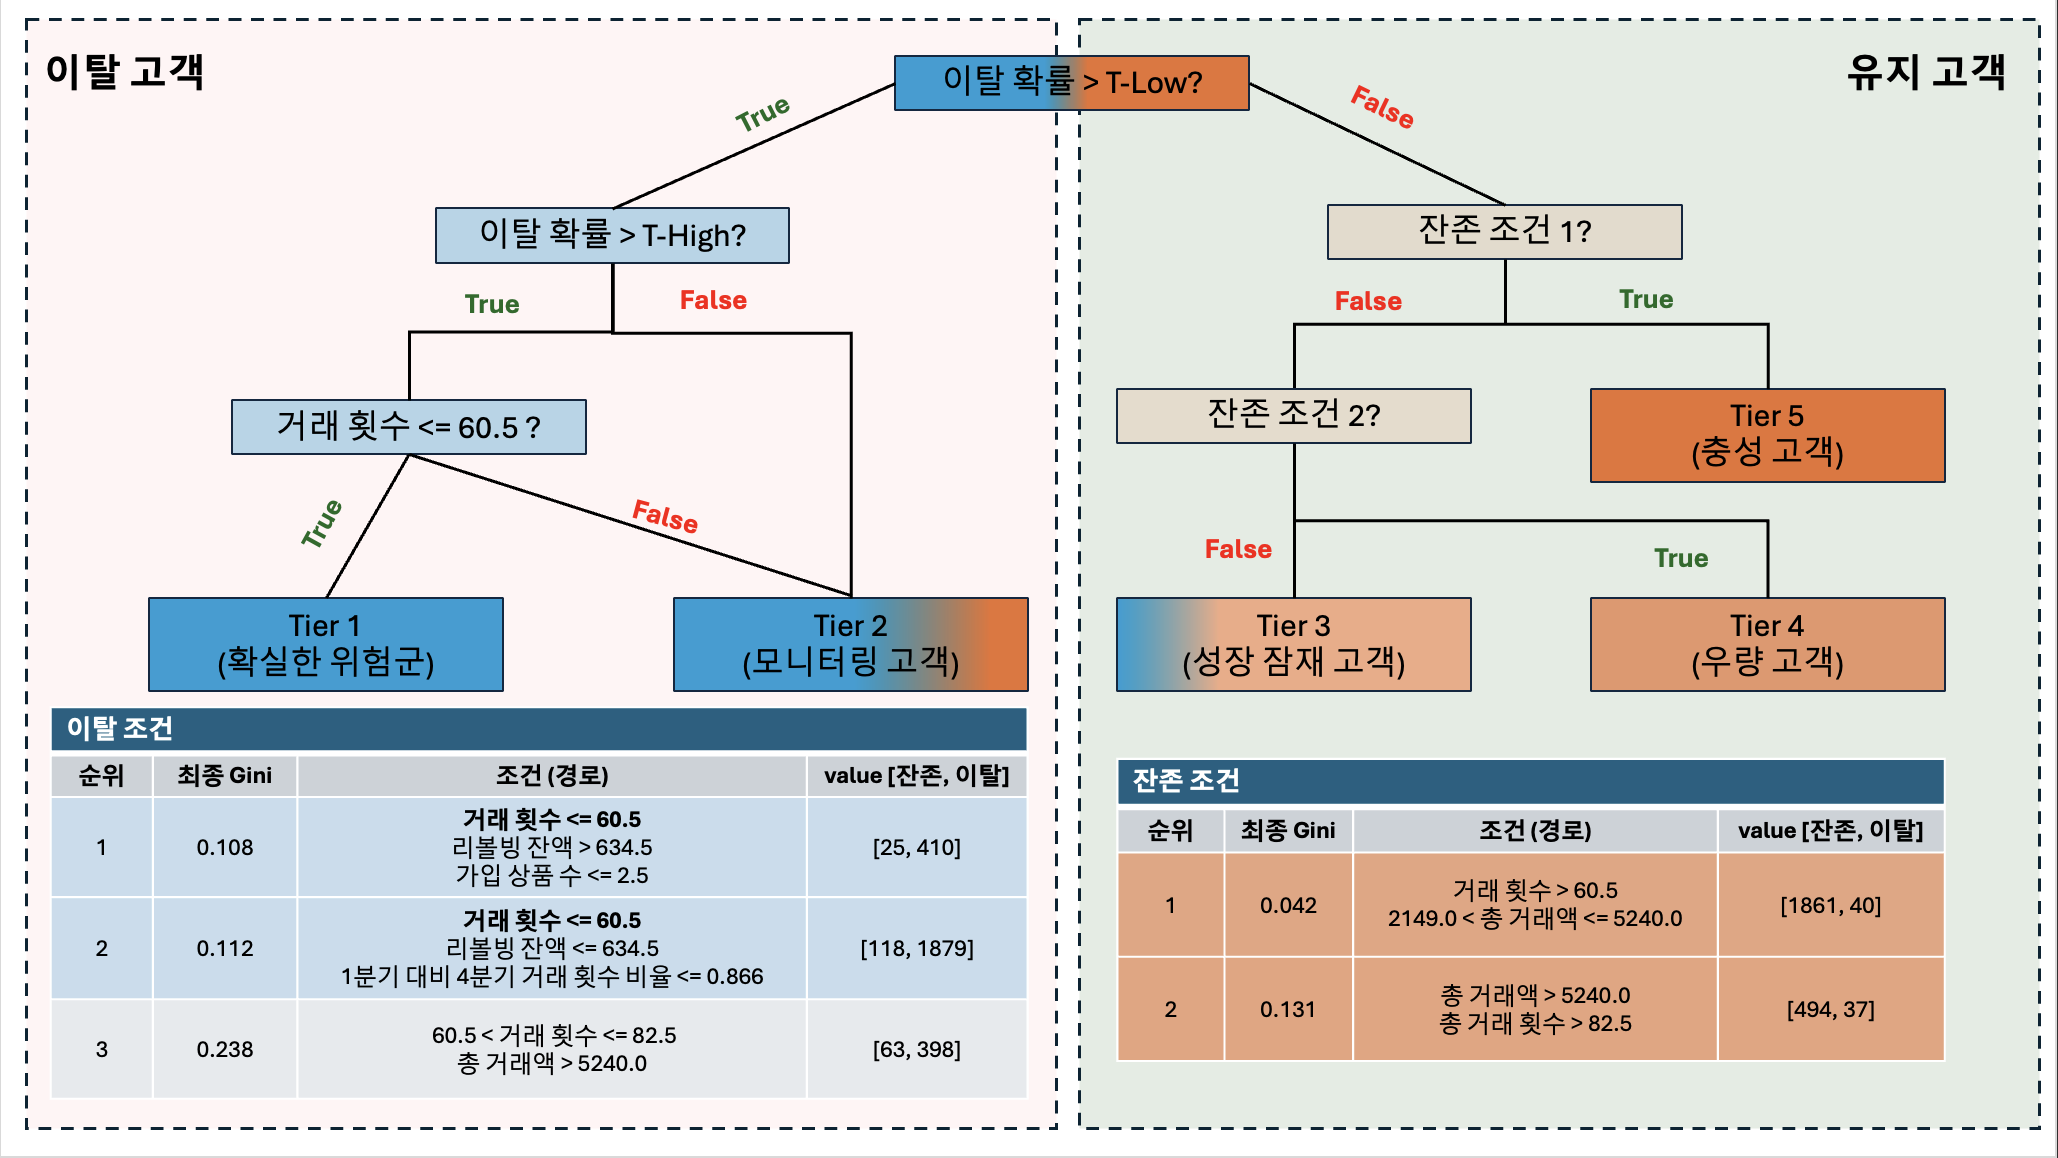

In [ ]:
# 고객관리를 위해 CLIENTNUM, 예측 결과 매칭
client_nums_series = df.loc[X.index, 'CLIENTNUM']
y_full_pred_proba = best_model_cat.predict_proba(X)[:, 1]

results_df = X.copy()
results_df['CLIENTNUM'] = client_nums_series
results_df['Attrited'] = y
results_df['Churn_Prob'] = y_full_pred_proba

## 2) Tier-Based Customer Segmentation

In [ ]:
# ----------------------------------------------------------------------
# Decision Tree 조건 컬럼 생성
# ----------------------------------------------------------------------
full_results_df = results_df.copy()

# 1. 이탈 조건 1 (E1): 최고 위험군
#   조건: 거래 횟수 <= 60.5 & 리볼빙 잔액 > 634.5 & 가입 상품 수 <= 2.5
full_results_df['DT_Cond_E1'] = (
    (full_results_df['Total_Trans_Ct'] <= 60.5) &
    (full_results_df['Total_Revolving_Bal'] > 634.5) &
    (full_results_df['Total_Relationship_Count'] <= 2.5)
)

# 2. 이탈 조건 2 (E2): 대규모 위험군
#   조건: 거래 횟수 <= 60.5 & 리볼빙 잔액 <= 634.5 & 1분기 대비 4분기 거래 횟수 비율 <= 0.866
full_results_df['DT_Cond_E2'] = (
    (full_results_df['Total_Trans_Ct'] <= 60.5) &
    (full_results_df['Total_Revolving_Bal'] <= 634.5) &
    (full_results_df['Total_Ct_Chng_Q4_Q1'] <= 0.866)
)

# 3. 잔존 조건 2 (S2): 우량 고객군(Tier-4)
#   조건: 거래 횟수 > 82.5 & 총 거래액 > 5240.0

full_results_df['DT_Cond_S2'] = (
    (full_results_df['Total_Trans_Ct'] > 82.5) &
    (full_results_df['Total_Trans_Amt'] >5240.0))


# 4. 잔존 조건 1 (S1): 확정 안정군(Tier-5)
#   조건: 거래 횟수 > 60.5 & 총 거래액 <= 5240.0 & 총 거래액 > 2149.0

full_results_df['DT_Cond_S1'] = (
    (full_results_df['Total_Trans_Ct'] > 60.5) &
    (full_results_df['Total_Trans_Amt'] <= 5240.0) &
    (full_results_df['Total_Trans_Amt'] > 2149.0)
)

In [ ]:
# T_High, T_Low 값 설정 (이전 대화에서 계산된 값)
T_High = 0.7221
T_Low = 0.4915

# ----------------------------------------------------------------------
# 1. 초기화: 이탈 고객은 N/A, 잔존 고객은 기본적으로 Tier-3로 시작
# ----------------------------------------------------------------------
full_results_df['Risk_Tier'] = 'Tier-3' # 안전군 중 가장 기본 Tier로 초기화
full_results_df.loc[full_results_df['Attrited'] == 1, 'Risk_Tier'] = 'N/A' # 이탈 고객은 N/A 유지

not_attrited_mask = (full_results_df['Attrited'] == 0)
churn_prob = full_results_df['Churn_Prob']

# ----------------------------------------------------------------------
# 2. Tier 1 정의 (최고 집중 관리)
#    조건: Churn_Prob >= T_High AND (이탈 조건 1 OR 이탈 조건 2)
# ----------------------------------------------------------------------
tier1_mask = (
    not_attrited_mask &
    (churn_prob >= T_High) &
    (full_results_df['DT_Cond_E1'] | full_results_df['DT_Cond_E2']) # 이탈 조건 1 또는 2
)
full_results_df.loc[tier1_mask, 'Risk_Tier'] = 'Tier-1'


# ----------------------------------------------------------------------
# 3. Tier 2 정의 (중간 모니터링)
#    조건: Churn_Prob >= T_Low AND Tier 1이 아닌 모든 잔존 고객
# ----------------------------------------------------------------------
# Tier 2 마스크: Churn_Prob >= T_Low 이면서 Tier 1이 아닌 잔존 고객
tier2_mask = (
    not_attrited_mask &
    (churn_prob >= T_Low) &
    (~tier1_mask) # Tier 1에 할당되지 않은 모든 위험 고객
)
full_results_df.loc[tier2_mask, 'Risk_Tier'] = 'Tier-2'


# ----------------------------------------------------------------------
# 4. Tier 4 정의 (우량 고객군)
#    조건: Churn_Prob < T_Low AND 잔존 조건 2 충족
# ----------------------------------------------------------------------
tier4_mask = (
    not_attrited_mask &
    (churn_prob < T_Low) &
    (full_results_df['DT_Cond_S2'])
)
full_results_df.loc[tier4_mask, 'Risk_Tier'] = 'Tier-4'

# ----------------------------------------------------------------------
# 4. Tier 5 정의 (충성 고객군)
#    조건: Churn_Prob < T_Low AND 잔존 조건 1 충족
# ----------------------------------------------------------------------
tier5_mask = (
    not_attrited_mask &
    (churn_prob < T_Low) &
    (full_results_df['DT_Cond_S1'])
)
full_results_df.loc[tier5_mask, 'Risk_Tier'] = 'Tier-5'

# ----------------------------------------------------------------------
# 5. Tier 3 (나머지)
#    Tier 1, 2, 4, 5에 속하지 않는 모든 잔존 고객은 Tier-3로 남음 (초기화 단계에서 처리됨)
# ----------------------------------------------------------------------

In [ ]:
# 잔존 고객만 필터링(final_action_list)하여 최종 실행 목록 도출
final_action_list = full_results_df[
    full_results_df['Attrited'] == 0
].drop('Attrited', axis=1)

excluded_count_final = full_results_df[full_results_df['Risk_Tier'] == 'N/A' # <<-- 필터링 구문 정확히 수정
].shape[0]

tier_counts = final_action_list['Risk_Tier'].value_counts().rename('Count')
tier_proportions = final_action_list['Risk_Tier'].value_counts(normalize=True).mul(100).round(2).rename('Proportion (%)')
tier_summary = pd.concat([tier_counts, tier_proportions], axis=1)

print("✅ Final Action List (All retained customers from X_train + X_test):")
print(f"Total number of retained customers under management: {len(final_action_list)}")
print(f"Number of already churned customers: {excluded_count_final}")
print("-" * 50)
print(tier_summary.to_markdown())

### Overall Customer Trends Analysis

In [ ]:
tier_summary = (
    full_results_df.groupby('Risk_Tier')
    .agg({
        'Churn_Prob': 'mean',
        'Total_Trans_Ct': 'mean',
        'Total_Trans_Amt': 'mean',
        'Total_Revolving_Bal': 'mean',
        'Total_Ct_Chng_Q4_Q1': 'mean',
        'Total_Amt_Chng_Q4_Q1': 'mean',
        'Total_Relationship_Count': 'mean',
        'Months_Inactive_12_mon': 'mean'
    })
    .round(2).reset_index()
)

tier_summary

| Risk Tier | Average Churn Probability | Summary of Key Characteristics |
| :--------- | :-------: | :------------------------------------------------------------------------------ |
| **Tier-5** | **0%** | A **premium safe segment** with churn probability converging to 0% and a very high relationship count, indicating the strongest long-term loyalty and relationship stability. |
| **Tier-4** | **1%** | A **VIP high-value segment** that generates the highest current revenue, with transaction count and transaction amount overwhelmingly higher than those of all other tiers. |
| **Tier-3** | **4%** | A **general segment with growth potential**, characterized by low churn risk, the highest relationship count, and average activity levels. |
| **Tier-2** | **66%** | A **monitoring segment with potential to become high-value customers through activity recovery**. Although churn risk is high, these customers maintain relatively high revolving balances, contributing to profitability. |
| **Tier-1** | **90%** | An **urgent intervention segment** with the highest churn risk, characterized by extremely low transaction activity (both count and amount) and the lowest revolving balance. |

# **7. Customer Segment Analysis**

## 1) Remaining Customer Analysis

### Comparison Across Tiers

In [ ]:
# @title
tier_summary2 = tier_summary.copy()
df_all = tier_summary[tier_summary2['Risk_Tier'].str.contains('Tier-')].set_index('Risk_Tier')

# 3. Min/Max 값 계산 (전체 Tier 기준)
min_vals = df_all.min()
max_vals = df_all.max()

# 4. 분석 대상 Tier 선택 및 데이터 준비
selected_tiers = ['Tier-5', 'Tier-4', 'Tier-3']
tier_profiles = df_all.loc[selected_tiers]

# 5. 전체 Tier 기준 Min-Max Scaling 적용
df_norm = (tier_profiles - min_vals) / (max_vals - min_vals)


# Radar Chart 설정
features = ['Total_Trans_Ct', 'Total_Trans_Amt',
            'Total_Revolving_Bal', 'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1',
            'Total_Relationship_Count', 'Months_Inactive_12_mon']

df_norm = df_norm[features]
categories = features

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)

# y축 설정
ax.set_rlabel_position(0)
plt.yticks(np.arange(0, 1.1, 0.2), [f"{i:.1f}" for i in np.arange(0, 1.1, 0.2)], color="grey", size=8)
plt.ylim(0, 1)

# 색상 매핑
colors = {'Tier-5': 'green', 'Tier-4': 'blue', 'Tier-3':'salmon'}

# Tier별 데이터 추가 및 스타일 차별화
for tier in selected_tiers:
    values = df_norm.loc[tier].values.flatten().tolist()
    values += values[:1]

    line_w = 1.5
    fill_alpha = 0.1
    line_alpha = 0.5

    ax.plot(angles, values, linewidth=line_w, linestyle='solid', label=tier, color=colors[tier], alpha=line_alpha)
    ax.fill(angles, values, colors[tier], alpha=fill_alpha)

ax.set_title('Safe Tier Profiles (Tier-3 vs Tier-4 vs Tier-5)', size=12, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=10)
plt.show()

### Detailed Analysis with SHAP Value

In [ ]:
import shap

cols_to_drop = [
    'CLIENTNUM',
    'Attrited',
    'Churn_Prob',
    'DT_Cond_E1',
    'DT_Cond_E2',
    'DT_Cond_S1',
    'Risk_Tier'
]


X_full = full_results_df.drop(columns=cols_to_drop).copy()
explainer = shap.TreeExplainer(best_model_cat)

tier_list = ['Tier-3', 'Tier-4', 'Tier-5']


for tier in tier_list:
    # 1. 고객 필터링: 현재 Tier에 속하는 '잔존 고객'만 선택 (Attrited == 0)
    tier_indices = full_results_df[
        (full_results_df['Risk_Tier'] == tier)].index

    # 해당 Tier의 피처 데이터셋 (X_tier)
    X_tier = X_full.loc[tier_indices].copy()


    # Skip if there are no customers to analyze in this tier
    if len(X_tier) == 0:
        print(f"\n--- {tier} Customer Analysis (Retained Customers) ---")
        print(f"⚠️ No retained customers belong to {tier}, so SHAP analysis is skipped.")
        continue

    print(f"\n========================================================")
    print(f"✅ Starting {tier} Customer Analysis (Number of retained customers: {len(X_tier)})")
    print(f"========================================================")

    # 2. Calculate SHAP values
    # CatBoost may return a multi-output list, so only the values for class 1 (churn) are used
    shap_values_tier = explainer.shap_values(X_tier)

    # 3. Visualize SHAP results
    print(f"--- Distribution of churn drivers for {tier} customers (SHAP Summary Plot) ---")

    # Use summary_plot to examine the distribution of churn drivers for this tier
    shap.summary_plot(shap_values_tier, X_tier, max_display=7)  # Display up to 7 features

    # 4. Summary for interpreting SHAP results (mean absolute SHAP values)

    # Create a DataFrame using only the SHAP values for class 1 (churn)
    shap_df_tier = pd.DataFrame(
        # If shap_values_tier is returned as a list, select only class 1 (churn) values with [:, 1]
        shap_values_tier[:, 1] if isinstance(shap_values_tier, list) else shap_values_tier,
        columns=X_tier.columns,
        index=X_tier.index
    )

    # Calculate mean absolute SHAP values (feature importance)
    mean_abs_shap = shap_df_tier.abs().mean().sort_values(ascending=False)

    print(f"\n--- Mean Absolute SHAP Values for {tier} Customers (Top 7 Features) ---")
    print(mean_abs_shap.head(7))
    print("========================================================")

<p style="font-size:18px; line-height:1.8;">
  <b>💎 Tier-5 (Loyal Customers)</b><br>
  - The most stable segment, with churn probability converging to <b>0%</b>.<br>
  - Compared with Tier-4, this group shows lower transaction amount and transaction count, but <b>higher recent transaction frequency and nearly twice the relationship count.</b><br>
  - Revolving balance is relatively high compared to total transaction amount.<br>
  - <b>Recent transaction frequency and months of inactivity are the key factors that clearly distinguish retention from churn.</b><br>
  - Since loyalty and activity are already high, <b>the priority is not churn prevention but increasing spending volume.</b><br>
</p>


<p style="font-size:18px; line-height:1.8;">
  <b>⚠️ Tier-4 (High-Value Customers)</b><br>
  - A very stable customer segment with an average churn probability of <b>1%</b>.<br>
  - Interestingly, higher transaction amounts are associated with a greater likelihood of churn.<br>
  - Customer activity over the past 12 months is the key factor: <b>more months of inactivity, more contacts, and higher transaction amounts → higher churn risk</b><br>
  - Customers with lower relationship counts tend to have higher long-term churn risk.<br>
  - The number of services used is the lowest among all customer segments.<br>
  - <b>→ A tailored VIP strategy focused on strengthening customer relationships is needed, rather than simply increasing transactions.</b><br>
</p>


<p style="font-size:18px; line-height:1.8;">
  <b>🌱 Tier-3 (Customers with Growth Potential)</b><br>
  - This segment has a moderate average churn probability and strong growth potential.<br>
  - Customers tend to hold many products and show high transaction activity over the past year, but their total transaction volume remains relatively low.<br>
  - <b>When total transaction count is low or recent transaction frequency declines, churn probability increases sharply.</b><br>
  - If total transaction amount is high but recent transaction amount is low, this may indicate <b>interest-decline churn</b>.<br>
  - More months of inactivity and lower relationship counts over the past year are associated with higher churn risk.<br>
  - <b>→ Early detection of declining activity signals and personalized benefits or re-engagement strategies are needed.</b><br>
</p>

## 2) Churn Customer Analysis

### Comparison Across Tiers
* Since the goal is to transition customers into Tier-3, Tier-3 metrics are included for comparison.

In [ ]:
# @title
tier_summary2 = tier_summary.copy()
df_all = tier_summary[tier_summary2['Risk_Tier'].str.contains('Tier-')].set_index('Risk_Tier')

# 3. Min/Max 값 계산 (전체 Tier 기준)
min_vals = df_all.min()
max_vals = df_all.max()

# 4. 분석 대상 Tier 선택 및 데이터 준비
selected_tiers = ['Tier-3', 'Tier-2', 'Tier-1']
tier_profiles = df_all.loc[selected_tiers]

# 5. 전체 Tier 기준 Min-Max Scaling 적용
df_norm = (tier_profiles - min_vals) / (max_vals - min_vals)


# Radar Chart 설정
features = ['Total_Trans_Ct', 'Total_Trans_Amt',
            'Total_Revolving_Bal', 'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1',
            'Total_Relationship_Count', 'Months_Inactive_12_mon']

df_norm = df_norm[features]
categories = features

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)

# y축 설정
ax.set_rlabel_position(0)
plt.yticks(np.arange(0, 1.1, 0.2), [f"{i:.1f}" for i in np.arange(0, 1.1, 0.2)], color="grey", size=8)
plt.ylim(0, 1)

# 색상 매핑
colors = {'Tier-3': 'salmon', 'Tier-2': 'orange', 'Tier-1':'navy'}

# Tier별 데이터 추가 및 스타일 차별화
for tier in selected_tiers:
    values = df_norm.loc[tier].values.flatten().tolist()
    values += values[:1]

    line_w = 1.5
    fill_alpha = 0.1
    line_alpha = 0.5

    ax.plot(angles, values, linewidth=line_w, linestyle='solid', label=tier, color=colors[tier], alpha=line_alpha)
    ax.fill(angles, values, colors[tier], alpha=fill_alpha)

ax.set_title('Risk Tier Profiles (Tier-3 vs Tier-2 vs Tier-1)', size=12, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=10)
plt.show()

### Detailed Analysis with SHAP Value

In [ ]:
import shap

cols_to_drop = [
    'CLIENTNUM',
    'Attrited',
    'Churn_Prob',
    'DT_Cond_E1',
    'DT_Cond_E2',
    'DT_Cond_S1',
    'Risk_Tier'
]


X_full = full_results_df.drop(columns=cols_to_drop).copy()
explainer = shap.TreeExplainer(best_model_cat)

tier_list = ['Tier-1', 'Tier-2']


for tier in tier_list:
    # 1. Filter customers: select only retained customers in the current tier
    tier_indices = full_results_df[
        (full_results_df['Risk_Tier'] == tier)
    ].index

    # Feature dataset for the current tier (X_tier)
    X_tier = X_full.loc[tier_indices].copy()

    # Skip if there are no customers to analyze in this tier
    if len(X_tier) == 0:
        print(f"\n--- {tier} Customer Analysis (Retained Customers) ---")
        print(f"⚠️ No retained customers belong to {tier}, so SHAP analysis is skipped.")
        continue

    print(f"\n========================================================")
    print(f"✅ Starting {tier} Customer Analysis (Number of retained customers: {len(X_tier)})")
    print(f"========================================================")

    # 2. Calculate SHAP values
    # CatBoost may return a multi-output list, so only the values for class 1 (churn) are used
    shap_values_tier = explainer.shap_values(X_tier)

    # 3. Visualize SHAP results
    print(f"--- Distribution of churn drivers for {tier} customers (SHAP Summary Plot) ---")

    # Use summary_plot to examine the distribution of churn drivers for this tier
    shap.summary_plot(shap_values_tier, X_tier, max_display=7)  # Display up to 7 features

    # 4. Summary for interpreting SHAP results (mean absolute SHAP values)

    # Create a DataFrame using only the SHAP values for class 1 (churn)
    shap_df_tier = pd.DataFrame(
        # If shap_values_tier is returned as a list, select only class 1 (churn) values with [:, 1]
        shap_values_tier[:, 1] if isinstance(shap_values_tier, list) else shap_values_tier,
        columns=X_tier.columns,
        index=X_tier.index
    )

    # Calculate mean absolute SHAP values (feature importance)
    mean_abs_shap = shap_df_tier.abs().mean().sort_values(ascending=False)

    print(f"\n--- Mean Absolute SHAP Values for {tier} Customers (Top 7 Features) ---")
    print(mean_abs_shap.head(7))
    print("========================================================")

<p style="font-size:18px; line-height:1.8;">
  <b>🟠 Tier-2 (Monitoring Customers)</b><br>
  - <b>With an average churn probability of 66%, this segment represents customers in the pre-churn stage, on the path toward Tier-1.</b><br>
  - Both activity levels and revolving balance are lower than those of Tier-3.<br>
  - Since transaction count contributes most strongly to churn, <b>recovering transaction frequency</b> is the key priority.<br>
  - Although the effect of total transaction amount is less clear, <b>the frequency and recency of recent transactions</b> have a clear impact.<br>
  - Churn risk increases significantly as the number of products used decreases.<br>
  - <b>→ A strategy is needed to restore transaction activity while also expanding product experience and encouraging mid-term growth.</b>
</p>
<br>

<p style="font-size:18px; line-height:1.8;">
  <b>🚨 Tier-1 (Customers Requiring Immediate Action)</b><br>
  - <b>This is the highest-risk churn segment (already characterized by fewer than 60 transactions).</b><br>
  - As transaction count decreases, churn probability rises sharply.<br>
  - Even when transaction amount is high, low activity levels are associated with a greater likelihood of churn.<br>
  - Revolving balance is generally low and does not directly help maintain retention.<br>
  - In other words, <b>“high-spending but inactive customers” are the most at risk.</b><br>
  - Core pattern: <b>transaction count ↓ / transaction amount ↑ / revolving balance ↓</b><br>
  - <b>→ Immediate reactivation campaigns, personalized rewards, and recovery of transaction frequency are required.</b><br>
</p>

# **8. Final Strategy Summary**

| Index | Category | Features |
|:------|:---------|:---------|
| **Activity** | Transaction-related metrics | `Total_Trans_Ct`, `Total_Trans_Amt`, `Total_Revolving_Bal` |
| **Trend** | Transaction changes and inactivity | `Total_Ct_Chng_Q4_Q1`, `Total_Amt_Chng_Q4_Q1`, `Months_Inactive_12_mon` |
| **Lock-in** | Customer relationship strength | `Total_Relationship_Count` |

* The analysis and strategy can be broadly organized into three categories. For readability, the features were grouped accordingly.

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_summary = tier_summary.copy().set_index('Risk_Tier')
df_summary = df_summary.drop('N/A', axis=0)



def calculate_tier_indices(df):
    """Min-Max Scaling 및 Index를 계산합니다. (활동성 3, 추세 3, 관계 1)"""

    # Feature Category Definition (기존 코드의 정의를 따름)
    activity_features = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal']
    trend_features = ['Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1', 'Months_Inactive_12_mon']
    lockin_features = ['Total_Relationship_Count']

    df_normalized = df.copy()

    for col in df.columns:
        min_val = df[col].min()
        max_val = df[col].max()

        if max_val == min_val:
            df_normalized[col] = 0
            continue

        # Min-Max Scaling (0 ~ 1)
        df_normalized[col] = (df[col] - min_val) / (max_val - min_val)

        # 부정적인 지표 (Months_Inactive_12_mon) 역변환 (1 - 값) 적용
        if col == 'Months_Inactive_12_mon':
            df_normalized[col] = 1 - df_normalized[col]

    results = pd.DataFrame(index=df.index)

    # Index 계산 (0 ~ 100점)
    # Trend Index는 버블 크기로 사용하기 위해 100점 만점으로 변경
    results['Activity_Index'] = df_normalized[activity_features].mean(axis=1) * 100
    results['Trend_Index'] = df_normalized[trend_features].mean(axis=1) * 100
    results['Lockin_Index'] = df_normalized[lockin_features].iloc[:, 0] * 100

    return results.reset_index()

df_indices = calculate_tier_indices(df_summary)

# --- 3. 버블 차트 시각화 (Trend vs Activity, Size = Lockin) ---

# 색상 설정 (Tier별 색상 유지)
colors = {
    'Tier-1': 'red', 'Tier-2': 'orange', 'Tier-3': 'lightblue',
    'Tier-4': 'grey', 'Tier-5': 'green'
}

# Lockin Index를 버블 크기에 매핑
# Lockin Index (0~100)를 적절한 버블 크기 범위 (예: 200 ~ 3500)로 변환
min_size = 200
max_size = 3500
df_indices['Bubble_Size'] = np.interp(
    df_indices['Lockin_Index'],
    (df_indices['Lockin_Index'].min(), df_indices['Lockin_Index'].max()),
    (min_size, max_size)
)

plt.figure(figsize=(12, 9))

# Scatter Plot (Bubble Chart) 생성
for tier in df_indices['Risk_Tier']:
    data = df_indices[df_indices['Risk_Tier'] == tier]

    plt.scatter(
        data['Trend_Index'],   # X-axis: Trend Index (추세/미래 안정성)
        data['Activity_Index'], # Y-axis: Activity Index (활동성/수익 기여)
        label=tier,
        color=colors[tier],
        s=data['Bubble_Size'],  # Size: Lockin Index (관계 안정성)
        alpha=0.6,
        edgecolors='black',
        linewidth=1.5
    )

    # Tier 이름 라벨링
    plt.annotate(
        tier,
        (data['Trend_Index'].iloc[0], data['Activity_Index'].iloc[0]),
        fontsize=12,
        fontweight='bold',
        ha='center', va='center',
        color='black'
    )

# 중앙선 (Median) 추가하여 4분면 분할
median_trend = df_indices['Trend_Index'].median()
median_activity = df_indices['Activity_Index'].median()

plt.axvline(median_trend, color='darkgray', linestyle='--', linewidth=1)
plt.axhline(median_activity, color='darkgray', linestyle='--', linewidth=1)

# Quadrant Labels (4분면 라벨)
plt.text(plt.xlim()[1] - 5, plt.ylim()[1] - 5, 'Ideal', color='darkgreen', fontsize=11, fontweight='bold', ha='right')
plt.text(plt.xlim()[0] + 5, plt.ylim()[1] - 5, 'High Value', color='red', fontsize=11, fontweight='bold')
plt.text(plt.xlim()[1] - 5, plt.ylim()[0] + 5, 'Stable', color='blue', fontsize=11, fontweight='bold', ha='right')
plt.text(plt.xlim()[0] + 10, plt.ylim()[0] + 5, 'Worst', color='darkred', fontsize=11, fontweight='bold')


plt.title('Strategic Bubble Chart: Activity vs Trend (Bubble Size = Lockin)', fontsize=16, pad=20)
plt.xlabel('Trend Index (Stability & Future Potential)', fontsize=14)
plt.ylabel('Activity Index (Current Contribution & Value)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)

# Lockin Index 범례(Legend)를 위한 더미 데이터 생성
legend_sizes = [df_indices['Lockin_Index'].min(), df_indices['Lockin_Index'].median(), df_indices['Lockin_Index'].max()]
legend_labels = [f'{s:.1f} (Low)' if s == df_indices['Lockin_Index'].min() else f'{s:.1f} (High)' if s == df_indices['Lockin_Index'].max() else f'{s:.1f}' for s in legend_sizes]
legend_bubble_sizes = np.interp(legend_sizes, (df_indices['Lockin_Index'].min(), df_indices['Lockin_Index'].max()), (min_size, max_size))

legend_lockin = plt.legend(
    [plt.scatter([], [], s=size, color='gray', alpha=0.6) for size in legend_bubble_sizes],
    legend_labels,
    title='Lockin Index Score',
    loc='lower left',
    bbox_to_anchor=(1.02, 0.7),
    frameon=True,
    fontsize=10
)


plt.tight_layout(rect=[0, 0, 1.0, 1.0])
plt.show()

# 최종 Index 테이블 출력
print("\n--- Final Tier Indices (0~100 Score) ---")
print(df_indices[['Risk_Tier', 'Activity_Index', 'Trend_Index', 'Lockin_Index']].round(1).set_index('Risk_Tier'))

<table>
<tr>
  <th>Tier</th>
  <th>Core Objective & Strategic Direction</th>
  <th>Activity & Revenue Growth</th>
  <th>Risk Management & Churn Prevention</th>
  <th>Relationship Strengthening & Lock-in</th>
</tr>

<tr>
  <td style="background-color:#E6F4EA;"><b>Tier-5</b></td>
  <td>Increase Activity and Reinforce the Loyalty Loop</td>
  <td>Relationship-based upselling (additional products / higher-tier offers), incentives to sustain activity</td>
  <td>Early warning after 2 months of inactivity and immediate RM-provided benefits (proactive risk management)</td>
  <td>Build a customer feedback loop (beta groups, referrals)</td>
</tr>

<tr>
  <td style="background-color:#E8F0FE;"><b>Tier-4</b></td>
  <td>Recognize Relationship Value and Hedge Risk</td>
  <td>Increase cashback rates (activity-based rewards)</td>
  <td>Early warning after 2 months of inactivity and immediate RM-provided benefits (same risk response as Tier-5)</td>
  <td>Offer exclusive VVIP benefits upon reaching target spending levels (value recognition / relationship strengthening)</td>
</tr>

<tr>
  <td style="background-color:#FFF3E0;"><b>Tier-3</b></td>
  <td>Defend Relationships and Strengthen Trend Signals</td>
  <td>Set low transaction-count goals and provide benefits upon achievement (stabilizing transaction frequency)</td>
  <td>Respond immediately at the moment inactivity changes from “0 to 1” (restore activity through personalized benefits)</td>
  <td>Fee waivers proportional to the number of products held (reinforcing lock-in value)</td>
</tr>

<tr>
  <td style="background-color:#FFEBEE;"><b>Tier-2</b></td>
  <td>Build Continuity → Increase Spending → Deepen Relationships</td>
  <td>Promote transaction consistency (challenge of 82.5+ transactions), suggest interest-based spending targets (amount growth)</td>
  <td>Provide customer-friendly management for revolving-balance users</td>
  <td>Cross-selling without fee burden, present Tier-3 upgrade criteria</td>
</tr>

<tr>
  <td style="background-color:#FCE4EC;"><b>Tier-1</b></td>
  <td>Achieve the Minimum Activity Goal</td>
  <td>Target at least 60.5 transactions and increase transaction amount up to 2,149</td>
  <td>Mission-based challenges and sequential goal setting based on decision tree rules</td>
  <td>Promotions that naturally encourage revolving balance usage (final mission)</td>
</tr>
</table>